# TabPFN-3 を Adult データで試す

GBDT 以外の選択肢として **TabPFN-3** を、UCI Adult (Census Income) で動かす探索ノートブック。
**前処理なし・無調整**のまま、学習データ量を変えて AUC と推論時間がどう動くかを見る。

- 再現用の実行スクリプト: `experiments/01_tabpfn/run.py`
- スイープ結果(JSON): `results/01_tabpfn/sweep.json`（このノートブックはそれを読み込む）


In [1]:
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd

# nbconvert 実行時の cwd は notebooks/ なので親をリポジトリ root とする
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

def load_dotenv(p):
    # TABPFN_TOKEN をプロセスへ渡す（.env は閲覧用に開かず、プログラムが読むだけ）
    if not p.exists():
        return
    for raw in p.read_text().splitlines():
        s = raw.strip()
        if s and not s.startswith('#') and '=' in s:
            k, _, v = s.partition('=')
            os.environ.setdefault(k.strip(), v.strip())

load_dotenv(ROOT / '.env')
print('TABPFN_TOKEN set:', bool(os.environ.get('TABPFN_TOKEN')))

TABPFN_TOKEN set: True


## データを見る

カテゴリ列と欠損(NaN)を含む生のテーブル。

In [2]:
from sklearn.datasets import fetch_openml

ds = fetch_openml('adult', version=2, as_frame=True)
X = ds.data
y = (ds.target == '>50K').astype(int)
print('shape:', X.shape, '| positive rate:', round(float(y.mean()), 3))
X.dtypes.astype(str).to_frame('dtype').assign(missing=X.isna().sum())

shape: (48842, 14) | positive rate: 0.239


,dtype,missing
age,int64,0
workclass,category,2799
fnlwgt,int64,0
education,category,0
education-num,int64,0
marital-status,category,0
occupation,category,2809
relationship,category,0
race,category,0
sex,category,0


## 前処理なしでそのまま投げる

TabPFN は生の DataFrame（カテゴリ列・欠損を含む）をそのまま受け取れる。one-hot もスケーリングも欠損補完も書かない。`fit()` はデータを保持するだけで、推論は `predict` 時の1回の forward pass（In-Context Learning）。

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tabpfn import TabPFNClassifier
from tabpfn.model_loading import ModelSource

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
demo_idx = X_tr.sample(1000, random_state=0).index  # デモ用に1000件

clf = TabPFNClassifier(
    device='cuda',
    model_path=ModelSource.get_classifier_v3().default_filename,
    random_state=0,
)
t0 = time.perf_counter(); clf.fit(X_tr.loc[demo_idx], y_tr.loc[demo_idx]); fit = time.perf_counter() - t0
t0 = time.perf_counter(); proba = clf.predict_proba(X_te)[:, 1]; pred = time.perf_counter() - t0
print(f'train=1000  AUC={roc_auc_score(y_te, proba):.4f}  fit={fit:.2f}s  predict={pred:.2f}s')

train=1000  AUC=0.9020  fit=0.70s  predict=2.38s


## 学習データ量を振る（AUC と推論時間）

`run.py` のスイープ結果を読み込んで可視化する。（無ければ先に `uv run python experiments/01_tabpfn/run.py` を実行）

,n_train,auc,accuracy,fit_sec,predict_sec
0,1000,0.901520,0.849319,0.762276,2.439682
1,5000,0.909417,0.857304,0.319777,3.754755
2,10000,0.913188,0.858839,0.313874,6.706442
3,20000,0.915017,0.859863,0.362829,14.830297
4,39073,0.917378,0.861603,0.474501,39.051426


saved figure -> /workspace/articles/images/tabpfn_sweep.png


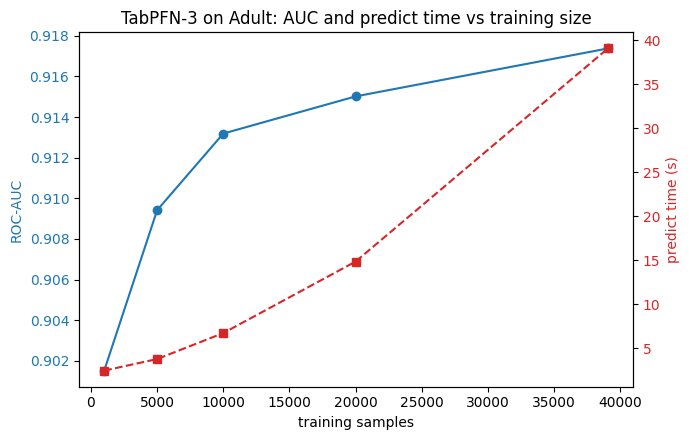

In [4]:
import matplotlib.pyplot as plt

sweep = json.loads((ROOT / 'results/01_tabpfn/sweep.json').read_text())
df = pd.DataFrame(sweep['results'])
display(df)

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(df['n_train'], df['auc'], 'o-', color='tab:blue')
ax1.set_xlabel('training samples')
ax1.set_ylabel('ROC-AUC', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(df['n_train'], df['predict_sec'], 's--', color='tab:red')
ax2.set_ylabel('predict time (s)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_title('TabPFN-3 on Adult: AUC and predict time vs training size')
fig.tight_layout()

out = ROOT / 'articles/images/tabpfn_sweep.png'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=130, bbox_inches='tight')
print('saved figure ->', out)
plt.show()

## 所見

- 学習データを増やすほど AUC は上がる（約 0.90 → 0.92弱）。ただし TabPFN は推論時に学習データ全体を文脈に入れるため、**`predict` は学習サイズとともに顕著に伸びる**（数秒 → 数十秒）。`fit` はほぼ一瞬のまま。
- 無調整・前処理なしのまま、公開されている LightGBM の Adult 参照スコア（≈0.92–0.93）に肉薄する。
- 旧 v2 では学習データの目安が ~1万行だったが、v3 では全量(約3.9万行)も問題なく動いた。